In [1]:
#load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load the dataset
df=pd.read_excel("Apples_stock price dataset.xlsx")

In [3]:
df.head()

,timestamp,stock_price,nasdaq_index,sp500_index,inflation_rate,unemployment_rate,interest_rate,market_sentiment
0,2010-01-01 00:00:00,102.483571,7984.160950,2994.240923,4.585202,6.837412,1.175768,0.095094
1,2010-01-01 01:00:00,99.347236,7995.706186,2995.831788,2.628987,5.851430,1.918567,-0.241960
2,2010-01-01 02:00:00,103.315558,8000.887651,2998.119650,2.616145,6.235115,2.436716,-0.833554
3,2010-01-01 03:00:00,107.730823,7995.763963,3004.532651,3.115002,6.397255,2.369055,0.059836
4,2010-01-01 04:00:00,98.983464,8002.448861,2997.154387,4.270254,4.942654,1.929987,-0.223077


In [4]:
# Set as index (recommended for time filtering)
df.set_index('timestamp', inplace=True)

In [5]:
# Remove weekends (Saturday=5, Sunday=6)
df = df[df.index.dayofweek < 5]

In [6]:
# Keep only data between 9:30 AM and 4:00 PM
df = df.between_time("09:30", "16:00")

In [7]:
# Reset index 
df.reset_index(inplace=True)

In [8]:
df.head()

,timestamp,stock_price,nasdaq_index,sp500_index,inflation_rate,unemployment_rate,interest_rate,market_sentiment
0,2010-01-01 10:00:00,98.068478,8056.045268,3028.223289,4.708331,4.913421,1.715299,0.774117
1,2010-01-01 11:00:00,98.095471,8048.212134,3036.325757,4.074317,5.831791,2.032927,-0.368769
2,2010-01-01 12:00:00,101.672484,8029.145300,3032.338086,4.535430,6.591331,1.048660,0.412976
3,2010-01-01 13:00:00,90.934823,8040.171561,3026.971600,3.086910,6.021296,2.352782,0.203629
4,2010-01-01 14:00:00,91.915186,8038.693757,3021.006100,3.804967,6.340995,3.132975,-0.166600


In [9]:
df.shape

(20832, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20832 entries, 0 to 20831
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          20832 non-null  datetime64[ns]
 1   stock_price        20822 non-null  float64       
 2   nasdaq_index       20830 non-null  float64       
 3   sp500_index        20830 non-null  float64       
 4   inflation_rate     20829 non-null  float64       
 5   unemployment_rate  20831 non-null  float64       
 6   interest_rate      20832 non-null  float64       
 7   market_sentiment   20832 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.3 MB


In [11]:
df.describe()

,timestamp,stock_price,nasdaq_index,sp500_index,inflation_rate,unemployment_rate,interest_rate,market_sentiment
count,20832,20822.000000,20830.000000,20830.000000,20829.000000,20831.000000,20832.000000,20832.000000
mean,2015-09-15 20:11:36.774193408,300.023096,259176.213115,101488.436137,3.011392,4.994605,2.003553,0.002985
min,2010-01-01 10:00:00,21.246547,8029.145300,3016.975344,1.000243,3.000111,0.500283,-0.999990
25%,2012-11-08 05:30:00,248.566881,134780.177749,51594.407830,2.007902,3.987933,1.259693,-0.503291
50%,2015-09-16 01:00:00,300.112152,257960.680915,100987.444484,3.003215,4.999014,2.003332,0.007074
75%,2018-07-23 20:30:00,351.341024,385263.000117,151648.759954,4.019155,5.991199,2.754578,0.508448
max,2021-05-28 16:00:00,589.000000,507930.802000,200756.680777,4.999090,6.999877,3.499970,0.999898
std,NaN,91.486382,144500.525583,57291.185935,1.155226,1.156852,0.864543,0.579322


In [12]:
df.isnull().sum()

timestamp             0
stock_price          10
nasdaq_index          2
sp500_index           2
inflation_rate        3
unemployment_rate     1
interest_rate         0
market_sentiment      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[['stock_price', 'nasdaq_index', 'sp500_index']] = (
    df[['stock_price', 'nasdaq_index', 'sp500_index']]
    .ffill()
    .bfill()
)
df[['inflation_rate', 'unemployment_rate']] = (
    df[['inflation_rate', 'unemployment_rate']]
    .ffill()
)
df.fillna(method='bfill', inplace=True)
df.isnull().sum()

timestamp            0
stock_price          0
nasdaq_index         0
sp500_index          0
inflation_rate       0
unemployment_rate    0
interest_rate        0
market_sentiment     0
dtype: int64

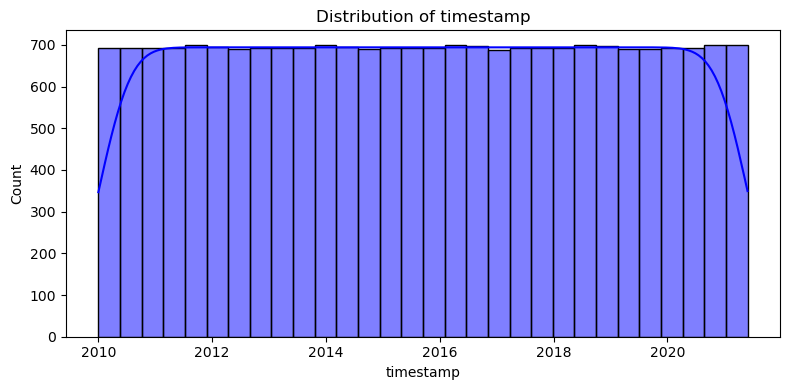

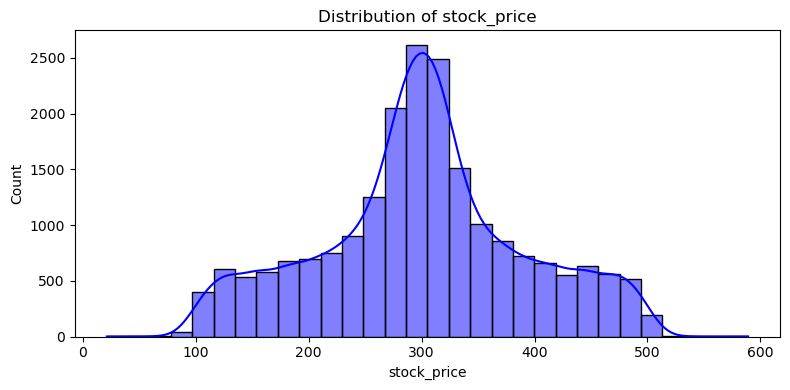

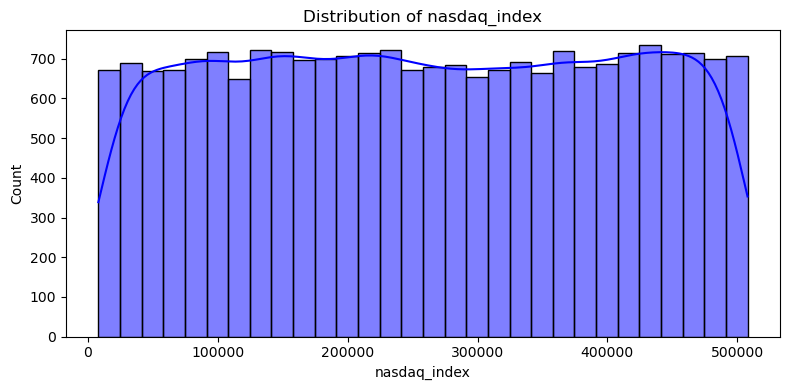

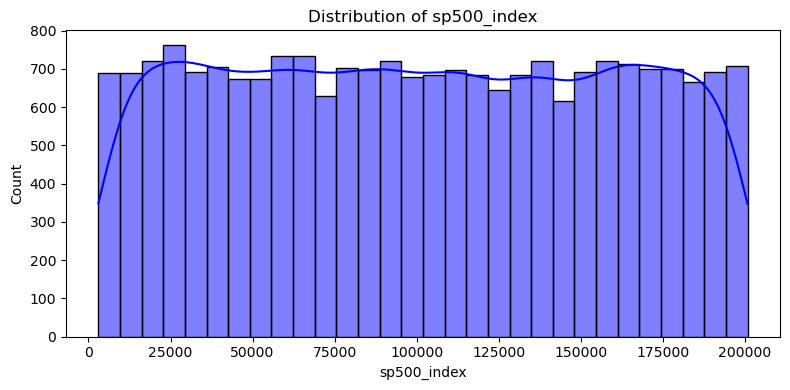

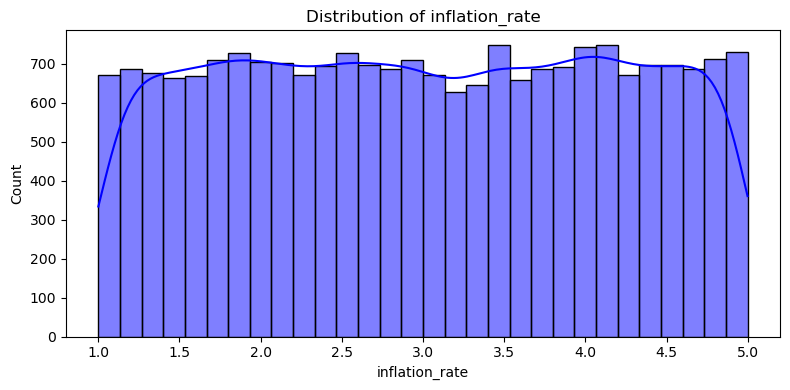

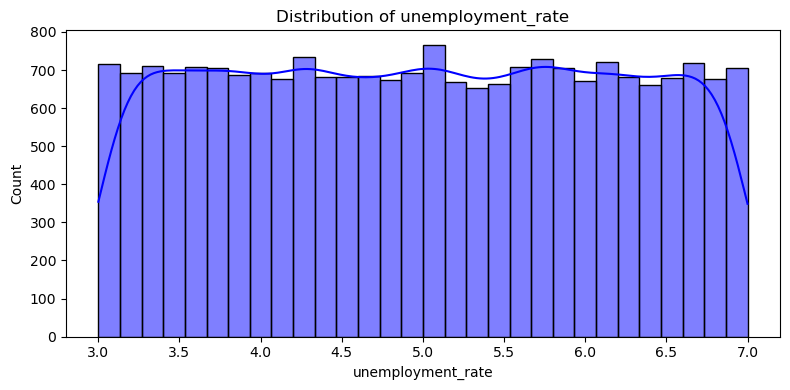

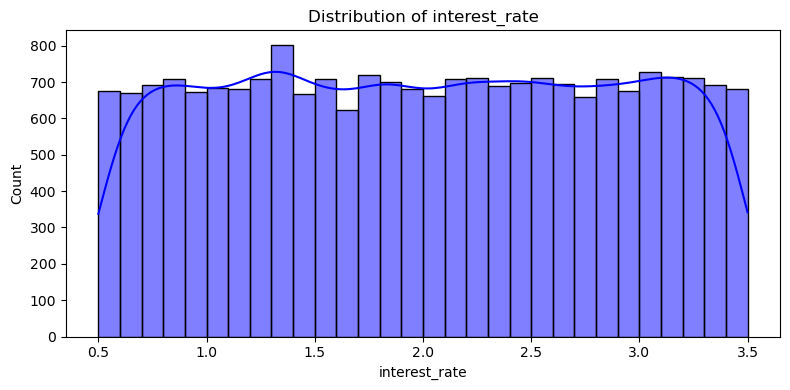

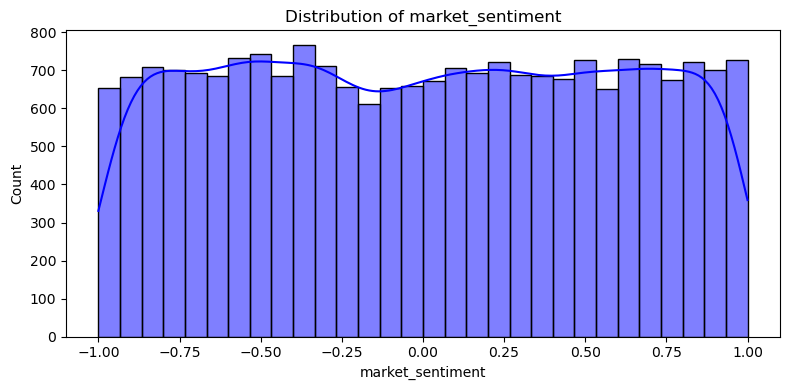

In [15]:
for col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=30, color="blue")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()

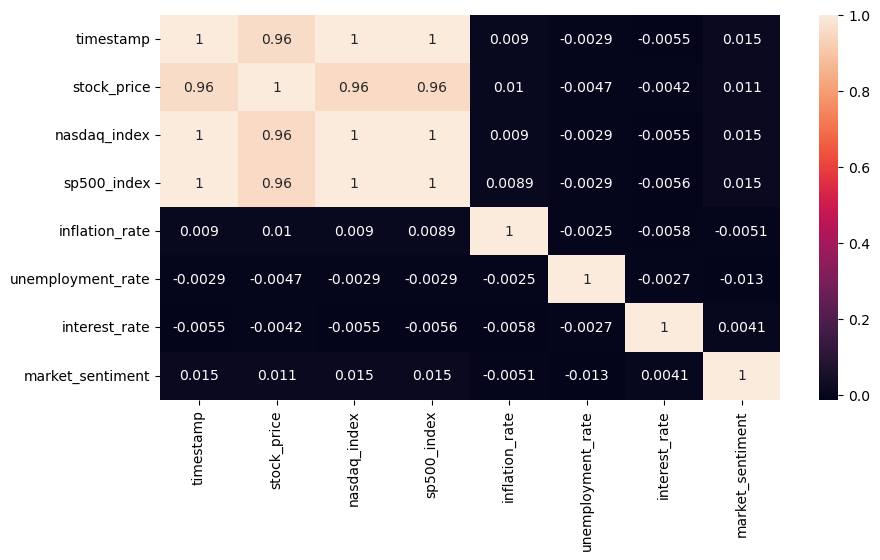

In [16]:
### correlation analysis
corr = df[df.columns].corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True)
plt.show()

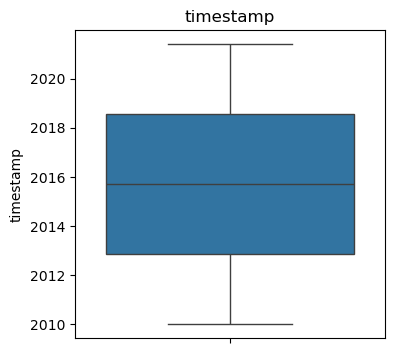

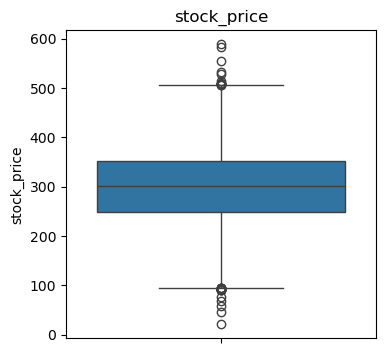

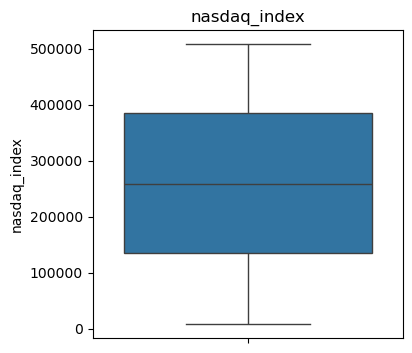

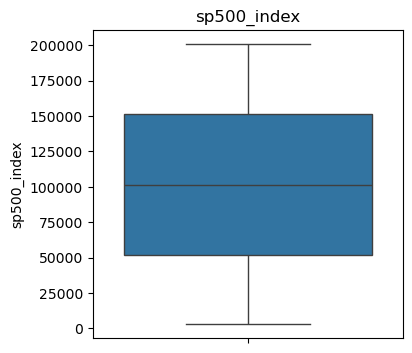

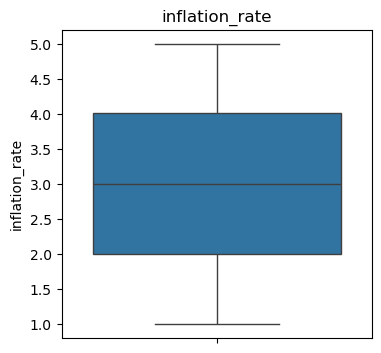

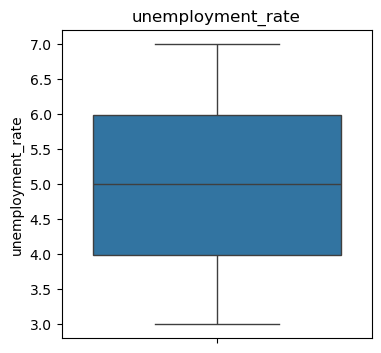

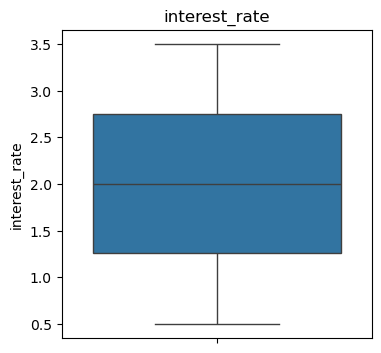

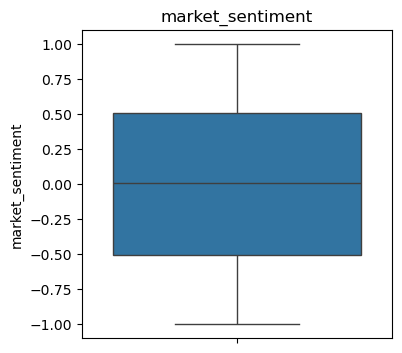

In [17]:
for col in df:
    plt.figure(figsize=(4, 4))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

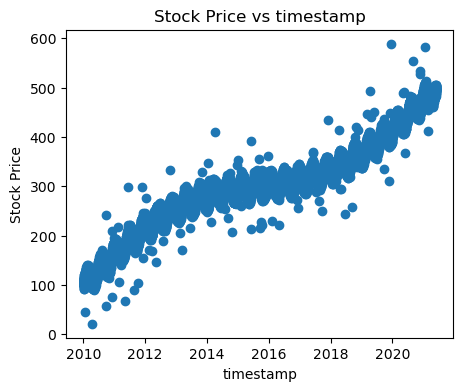

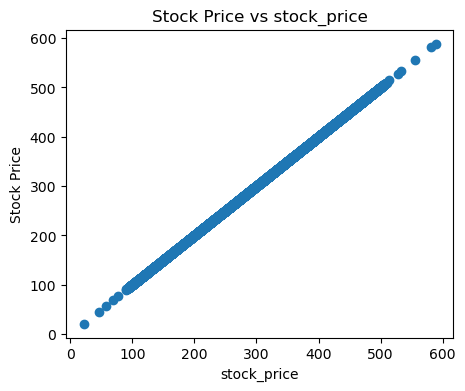

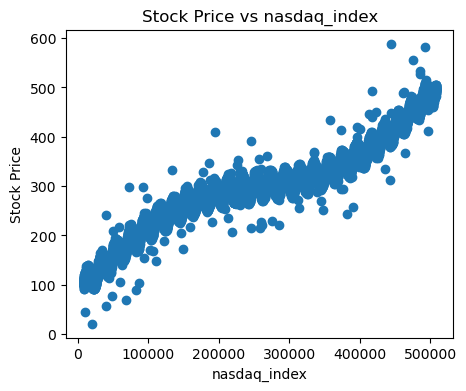

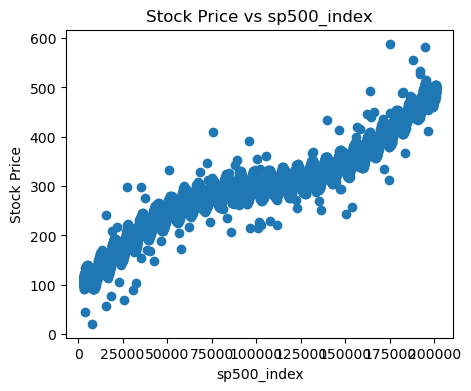

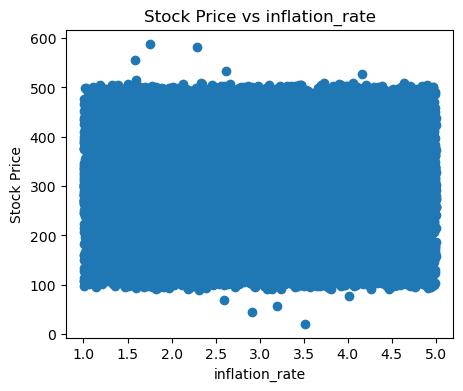

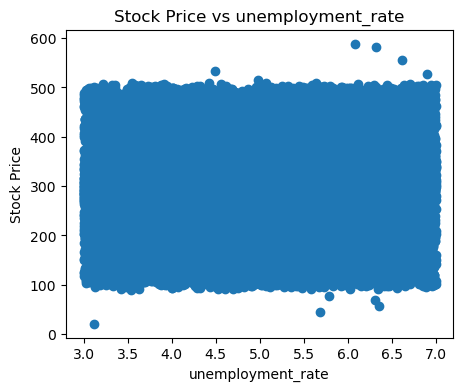

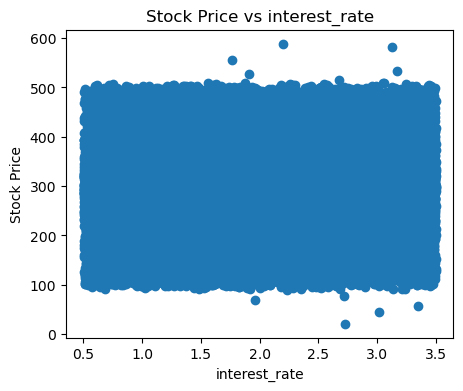

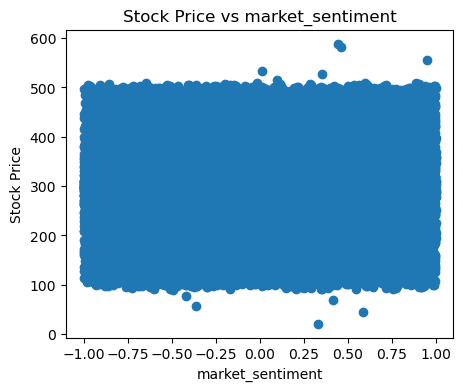

In [18]:
for col in df:
    plt.figure(figsize=(5, 4))
    plt.scatter(df[col], df['stock_price'])
    plt.xlabel(col)
    plt.ylabel('Stock Price')
    plt.title(f'Stock Price vs {col}')
    plt.show()

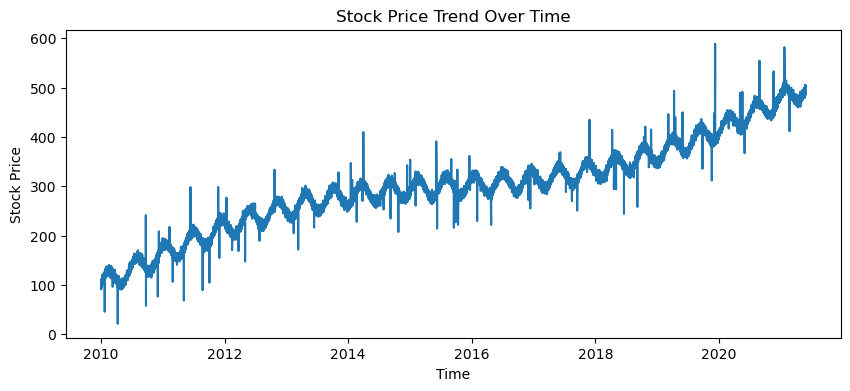

In [19]:
plt.figure(figsize=(10,4))
plt.plot(df['timestamp'], df['stock_price'])
plt.title("Stock Price Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns=['timestamp']))


In [21]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.drop(columns=['timestamp']).columns,
    index=df.index
)

print(scaled_df.head())

   stock_price  nasdaq_index  sp500_index  inflation_rate  unemployment_rate  \
0    -2.206865     -1.737767    -1.718547        1.469107          -0.070155   
1    -2.206570     -1.737822    -1.718406        0.920257           0.723731   
2    -2.167479     -1.737954    -1.718476        1.319431           1.380316   
3    -2.284825     -1.737877    -1.718569        0.065482           0.887549   
4    -2.274111     -1.737887    -1.718673        0.687087           1.163913   

   interest_rate  market_sentiment  
0      -0.333426          1.331125  
1       0.033977         -0.641720  
2      -1.104533          0.707726  
3       0.403956          0.346352  
4       1.306411         -0.292737  


In [22]:
print(scaled_data.shape)

(20832, 7)


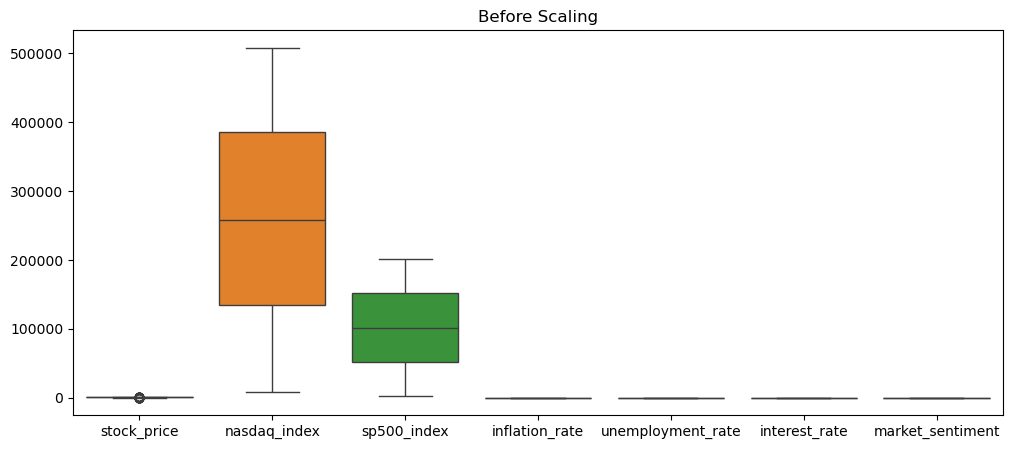

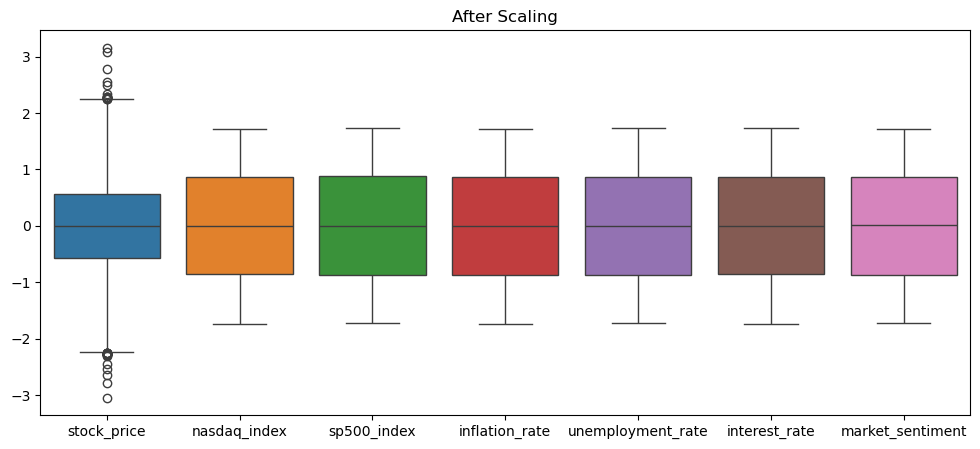

In [23]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df.drop(columns=['timestamp']))
plt.title("Before Scaling")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=scaled_df)
plt.title("After Scaling")
plt.show()


In [24]:
# Target and features
X = scaled_df.drop(columns=['stock_price'])
y = scaled_df['stock_price']

# Time-based split (80% train, 20% test)
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Result = []

def evaluate_model(y_true, y_pred, model_name):
    Result.append({
        "Model": model_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    })

In [26]:
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:i+time_steps].values)
        ys.append(y.iloc[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_lstm, y_lstm = create_sequences(X, y, time_steps)

split_lstm = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split_lstm], X_lstm[split_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:split_lstm], y_lstm[split_lstm:]


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')

lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=1)

lstm_pred = lstm.predict(X_test_lstm).flatten()

evaluate_model(y_test_lstm, lstm_pred, "LSTM")


Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0461
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0318
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0308
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0305
Epoch 5/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0308
Epoch 6/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0302
Epoch 7/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0303
Epoch 8/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0298
Epoch 9/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0295
Epoch 10/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0296
Epoch 11/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0298
Epoch 12/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0290
Epoch 13/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0288
Epoch 14/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0284
Epoch 15/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 7

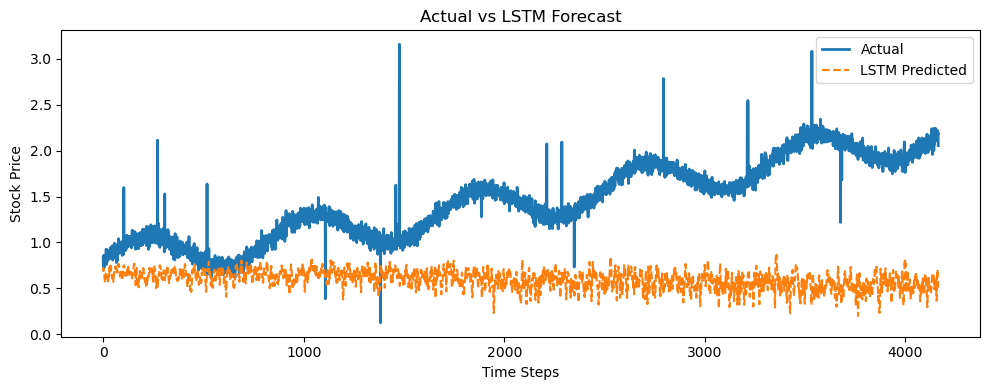

In [28]:
plt.figure(figsize=(10,4))
plt.plot(y_test_lstm, label="Actual", linewidth=2)
plt.plot(lstm_pred, label="LSTM Predicted", linestyle="--")
plt.title("Actual vs LSTM Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y_train, order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(y_test))

evaluate_model(y_test, arima_pred, "ARIMA")


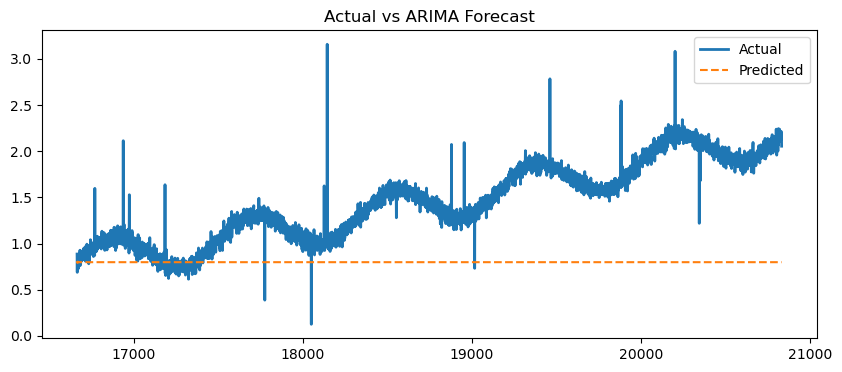

In [30]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, arima_pred, label="Predicted", linestyle="--")
plt.title("Actual vs ARIMA Forecast")
plt.legend()
plt.show()


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(0,1,1,5)  # weekly seasonality
)

sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(len(y_test))

evaluate_model(y_test, sarima_pred, "SARIMA")

In [ ]:
sarima_pred = pd.Series(sarima_pred, index=y_test.index)

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, sarima_pred, label="SARIMA Predicted", linestyle="--")
plt.title("Actual vs SARIMA Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from xgboost import XGBRegressor

# Step 1: ARIMA residuals
residuals = y_train - arima_fit.fittedvalues

# Step 2: Train XGBoost on residuals
xgb_res = XGBRegressor(n_estimators=200)
xgb_res.fit(X_train.iloc[1:], residuals.iloc[1:])

# Step 3: Forecast
arima_forecast = arima_pred
xgb_res_pred = xgb_res.predict(X_test)

hybrid_pred = arima_forecast + xgb_res_pred

evaluate_model(y_test, hybrid_pred, "Hybrid ARIMA + XGBoost")

In [ ]:
hybrid_pred = pd.Series(hybrid_pred, index=y_test.index)

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, hybrid_pred, label="Hybrid Predicted", linestyle="--")
plt.title("Actual vs Hybrid ARIMA + XGBoost Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(Result)
results_df = results_df.sort_values("rmse")  # primary ranking metric
results_df

In [ ]:
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "Hybrid ARIMA + XGBoost", "LSTM"],
    "MAE": [0.657292, 0.328543, 0.651737, 0.784625],
    "RMSE": [0.774499, 0.394377, 0.770083, 0.886648]
})
results.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
forecast_steps = 30 * 24

sarima_forecast = sarima_fit.get_forecast(steps=forecast_steps)
sarima_forecast_actual = sarima_forecast.predicted_mean
forecast_dates = pd.date_range(
    start=y.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq='H'
)
plt.figure(figsize=(12,5))

# recent history
plt.plot(
    y.index[-7*24:],
    y.values[-7*24:],
    label='Recent Historical',
    color='blue'
)

# forecast
plt.plot(
    forecast_dates,
    sarima_forecast_actual,
    label='SARIMA Hourly Forecast (30 Days)',
    linestyle='--',
    color='red'
)

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("SARIMA Hourly Forecast – Next 30 Days")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("Last actual price:", y.iloc[-1])
print("First forecast:", sarima_forecast_actual.iloc[0])
